In [1]:
import pandas as pd
import numpy as np
import pickle
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
import torch
from sklearn.preprocessing import LabelEncoder


In [2]:
warnings.filterwarnings('ignore')
print(f"XGBoost version: {xgb.__version__}")
print(f"CUDA avaiable: {torch.cuda.is_available}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    TREE_METHOD = 'hist'
    DEVICE = 'cuda'
else:
    TREE_METHOD = 'hist'
    DEVICE = 'cpu'
    
print(f"training on: {DEVICE}")

XGBoost version: 3.2.0
CUDA avaiable: <function is_available at 0x0000023E9B273690>
GPU: NVIDIA GeForce RTX 5080
training on: cuda


In [3]:
train_df = pd.read_parquet("train_df.parquet")
test_df = pd.read_parquet("test_df.parquet")

with open('feature_list.pkl', 'rb') as f:
    feature_info = pickle.load(f)
    
ALL_FEATURES = feature_info['ALL_FEATURES']
TARGET = feature_info['TARGET']


X_train = train_df[ALL_FEATURES].copy()
y_train = train_df[TARGET].copy()
X_test = test_df[ALL_FEATURES].copy()
y_test = test_df[TARGET].copy()

cat_cols = [f for f in ALL_FEATURES if X_train[f].dtype.kind == 'O' 
            or pd.api.types.is_string_dtype(X_train[f])]
print(f"Categorical features: {len(cat_cols)}")
print(f"Categorical columns:  {cat_cols}")

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_test[col]]).astype(str).fillna('UNKNOWN')
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str).fillna('UNKNOWN')).astype(int)
    X_test[col]  = le.transform(X_test[col].astype(str).fillna('UNKNOWN')).astype(int)
    label_encoders[col] = le

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target: {TARGET}")
print(f"Feature: {len(ALL_FEATURES)}")
print(f"\nTest storms")
print(test_df['floodEvent'].value_counts())

Categorical features: 7
Categorical columns:  ['occupancyType', 'ratedFloodZone', 'floodZoneCurrent', 'causeOfDamage', 'storm_intensity_cat', 'prop_wind_exposure', 'state']
Train: (720526, 49), Test: (189549, 49)
Target: buildingDamageAmount_2024_capped
Feature: 49

Test storms
floodEvent
Hurricane Sandy    135455
Hurricane Ian       38035
Hurricane Ivan      16059
Name: count, dtype: int64


In [4]:
print(X_train.dtypes.unique())
print(X_train['occupancyType'].dtype)
print(type(X_train['occupancyType'].iloc[0]))

[dtype('float64') dtype('int64')]
int64
<class 'numpy.int64'>


In [5]:
base = xgb.XGBRegressor(
    n_estimators = 1000,
    learning_rate = 0.05,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    tree_method = TREE_METHOD,
    device =DEVICE,
    random_state =  67,
    early_stopping_rounds = 50,
    eval_metric = 'rmse',
)

print("training XGBoost base model")
base.fit(
    X_train, y_train,
    eval_set = [(X_train, y_train),(X_test,y_test)],
    verbose = 50
)
print("baseline models complete")

training XGBoost base model
[0]	validation_0-rmse:105404.36986	validation_1-rmse:121617.52307
[50]	validation_0-rmse:70073.16659	validation_1-rmse:115320.83631
[100]	validation_0-rmse:66056.77960	validation_1-rmse:115094.79267
[128]	validation_0-rmse:64832.92881	validation_1-rmse:115176.88458
baseline models complete


In [6]:
y_pred = base.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae =  mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("── Baseline Model Performance ──────────────────")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE:  ${mae:,.0f}")
print(f"R²:   {r2:.4f}")

test_df['y_pred'] = y_pred
print("\n── Per-Storm Performance ───────────────────────")
for storm in test_df['floodEvent'].unique():
    mask = test_df['floodEvent'] == storm
    s_rmse = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
    s_mae = mean_absolute_error(y_test[mask], y_pred[mask])
    s_r2   = r2_score(y_test[mask], y_pred[mask])
    print(f"{storm:<25} RMSE: ${s_rmse:>10,.0f}  MAE: ${s_mae:>10,.0f}  R²: {s_r2:.4f}")

── Baseline Model Performance ──────────────────
RMSE: $114,929
MAE:  $59,549
R²:   0.1160

── Per-Storm Performance ───────────────────────
Hurricane Ian             RMSE: $   152,565  MAE: $    73,940  R²: 0.1665
Hurricane Sandy           RMSE: $    94,700  MAE: $    53,344  R²: 0.0266
Hurricane Ivan            RMSE: $   158,533  MAE: $    77,802  R²: 0.1768


── Top 20 Features ─────────────────────────────
                           feature  importance
           hurdat2_min_pressure_mb    0.148225
             buildingPropertyValue    0.092276
                         longitude    0.077916
            hurdat2_max_wind_speed    0.074055
                   elevated_binary    0.052153
                   obstructionType    0.045940
    totalBuildingInsuranceCoverage    0.038825
           buildingReplacementCost    0.037100
                        yearOfLoss    0.023719
                             state    0.023010
                     causeOfDamage    0.019290
                  post_firm_binary    0.018641
              building_age_at_loss    0.018365
                  prop_max_wind_kt    0.017936
             prop_dist_to_track_nm    0.017610
                prop_wind_exposure    0.017062
                       policyCount    0.016831
                     occupancyType    0.015069
numberOfFloorsInTheInsuredBuilding    0.014649
           

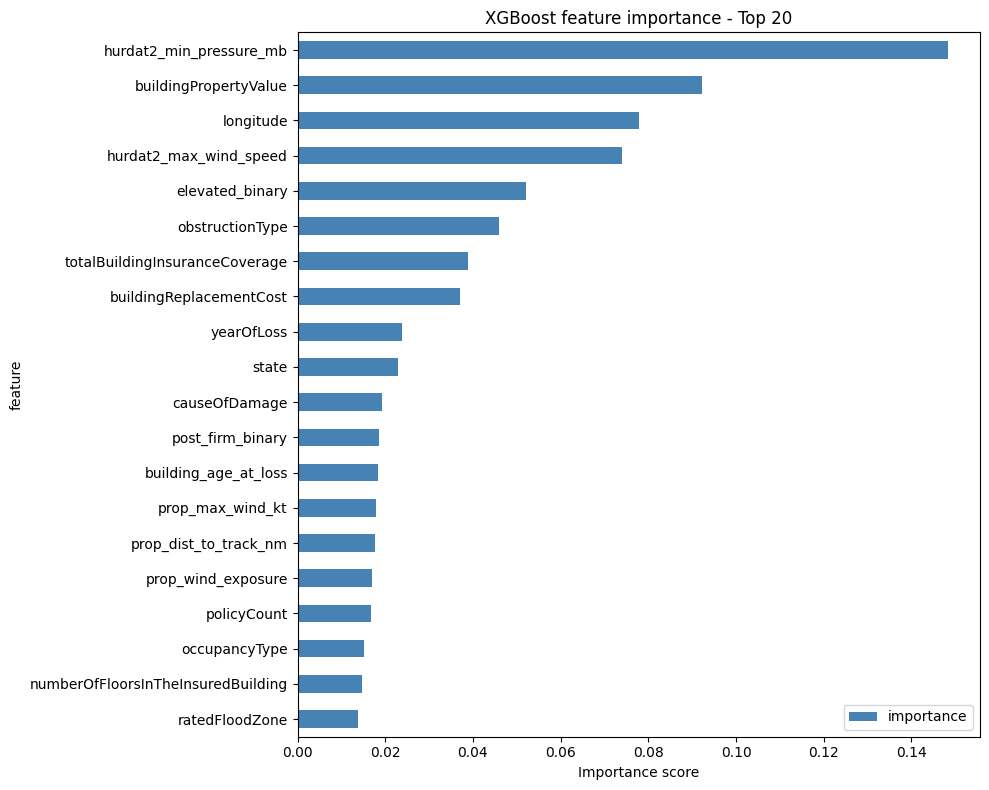

Feature importance saved ✅


In [7]:
importance_df = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': base.feature_importances_
}).sort_values('importance',ascending=False)

print("── Top 20 Features ─────────────────────────────")
print(importance_df.head(20).to_string(index=False))


fig, ax = plt.subplots(figsize= (10,8))
importance_df.head(20).sort_values("importance").plot.barh(
    x='feature', y='importance', ax=ax, color="steelblue"
)

ax.set_title("XGBoost feature importance - Top 20")
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig("feature importance.png", dpi=150)
plt.show() 
print("Feature importance saved ✅")

In [8]:
base.save_model('hurricane_severity_model.json')

print("Model saved to hurricane_severity_model.json ✅")
print(f"\nFinal metrics:")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  MAE:  ${mae:,.0f}")
print(f"  R²:   {r2:.4f}")

Model saved to hurricane_severity_model.json ✅

Final metrics:
  RMSE: $114,929
  MAE:  $59,549
  R²:   0.1160


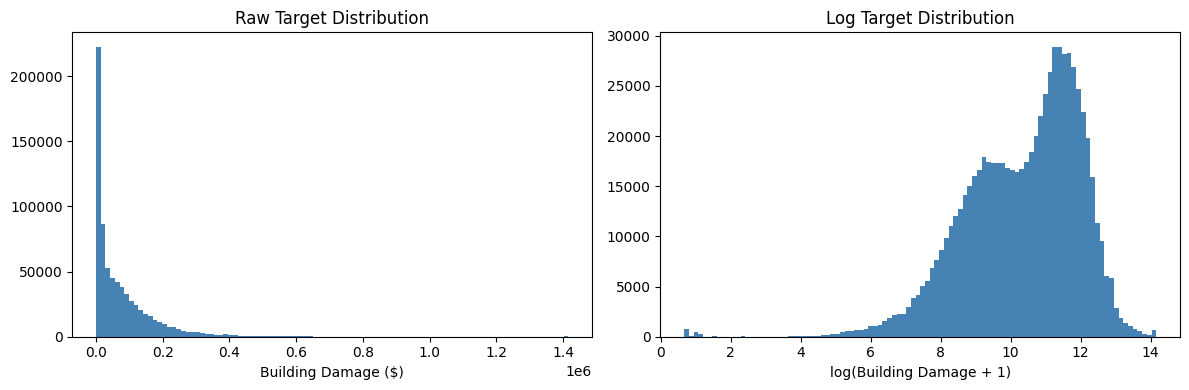

Skewness: 4.06
% of claims under $50k: 53.6%
% of claims under $100k: 72.5%


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Raw Target Distribution')
axes[0].set_xlabel('Building Damage ($)')
 
axes[1].hist(np.log1p(y_train), bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('Log Target Distribution')
axes[1].set_xlabel('log(Building Damage + 1)')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

print(f"Skewness: {y_train.skew():.2f}")
print(f"% of claims under $50k: {(y_train < 50000).mean()*100:.1f}%")
print(f"% of claims under $100k: {(y_train < 100000).mean()*100:.1f}%")

In [10]:
cat_cols = [f for f in ALL_FEATURES if pd.api.types.is_string_dtype(X_train[f])]
print(f"Encoding: {cat_cols}")

from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_test[col]]).astype(str).fillna('UNKNOWN')
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str).fillna('UNKNOWN')).astype(int)
    X_test[col]  = le.transform(X_test[col].astype(str).fillna('UNKNOWN')).astype(int)
    label_encoders[col] = le

print(f"String cols remaining: {[f for f in ALL_FEATURES if pd.api.types.is_string_dtype(X_train[f])]}")

Encoding: []
String cols remaining: []


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load
X_train = train_df[ALL_FEATURES].copy()
y_train = train_df[TARGET].copy()
X_test  = test_df[ALL_FEATURES].copy()
y_test  = test_df[TARGET].copy()

# Encode immediately after load
cat_cols = [f for f in ALL_FEATURES if pd.api.types.is_string_dtype(X_train[f])]
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_test[col]]).astype(str).fillna('UNKNOWN')
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str).fillna('UNKNOWN')).astype(int)
    X_test[col]  = le.transform(X_test[col].astype(str).fillna('UNKNOWN')).astype(int)
    label_encoders[col] = le
print(f"Encoded {len(cat_cols)} columns. String cols remaining: {[f for f in ALL_FEATURES if pd.api.types.is_string_dtype(X_train[f])]}")

# Log transform
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

# Split
X_tr, X_val, y_tr_raw, y_val_raw = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=67
)
print(f"Train: {X_tr.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Encoded 7 columns. String cols remaining: []
X_train: (720526, 49), y_train: (720526,)
Train: (648473, 49), Val: (72053, 49), Test: (189549, 49)


In [12]:
X_tr, X_val, y_tr_raw, y_val_raw = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=67
)

tuned_model = xgb.XGBRegressor(
    n_estimators          = 5000,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 10,
    tree_method           = TREE_METHOD,
    device                = DEVICE,
    random_state          = 67,
    early_stopping_rounds = 50,
    eval_metric           = 'rmse',
)

print("Training raw target model with validation split...")
tuned_model.fit(
    X_tr, y_tr_raw,
    eval_set=[(X_tr, y_tr_raw), (X_val, y_val_raw)],
    verbose=100
)

print(f"\nBest iteration: {tuned_model.best_iteration}")
print(f"Best score:     {tuned_model.best_score:.4f}")

Training raw target model with validation split...
[0]	validation_0-rmse:105691.86877	validation_1-rmse:102847.06670
[100]	validation_0-rmse:66156.92462	validation_1-rmse:65712.96749
[200]	validation_0-rmse:62727.71166	validation_1-rmse:63083.50881
[300]	validation_0-rmse:60819.73545	validation_1-rmse:61957.57014
[400]	validation_0-rmse:59427.13088	validation_1-rmse:61242.07773
[500]	validation_0-rmse:58180.79504	validation_1-rmse:60630.38722
[600]	validation_0-rmse:57237.13378	validation_1-rmse:60252.93665
[700]	validation_0-rmse:56389.64943	validation_1-rmse:59861.30002
[800]	validation_0-rmse:55548.33507	validation_1-rmse:59509.70247
[900]	validation_0-rmse:54878.14822	validation_1-rmse:59276.01419
[1000]	validation_0-rmse:54184.98417	validation_1-rmse:59049.38140
[1100]	validation_0-rmse:53597.11196	validation_1-rmse:58875.80992
[1200]	validation_0-rmse:53033.28194	validation_1-rmse:58707.37862
[1300]	validation_0-rmse:52487.91366	validation_1-rmse:58560.36123
[1400]	validation_0-r

In [13]:
y_pred = tuned_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("── Final Model Performance ─────────────────────")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE:  ${mae:,.0f}")
print(f"R²:   {r2:.4f}")

print("\n── Per-Storm Performance ───────────────────────")
for storm in test_df['floodEvent'].unique():
    mask   = (test_df['floodEvent'] == storm).values
    s_rmse = np.sqrt(mean_squared_error(y_test.values[mask], y_pred[mask]))
    s_mae  = mean_absolute_error(y_test.values[mask], y_pred[mask])
    s_r2   = r2_score(y_test.values[mask], y_pred[mask])
    n      = mask.sum()
    print(f"{storm:<25} n={n:>6,}  RMSE: ${s_rmse:>10,.0f}  MAE: ${s_mae:>9,.0f}  R²: {s_r2:.4f}")

# Save
tuned_model.save_model('hurricane_severity_model_v2.json')
print("\nModel saved ✅")

── Final Model Performance ─────────────────────
RMSE: $118,686
MAE:  $62,491
R²:   0.0572

── Per-Storm Performance ───────────────────────
Hurricane Ian             n=38,035  RMSE: $   159,214  MAE: $   76,788  R²: 0.0923
Hurricane Sandy           n=135,455  RMSE: $    99,826  MAE: $   57,177  R²: -0.0816
Hurricane Ivan            n=16,059  RMSE: $   148,904  MAE: $   73,457  R²: 0.2738

Model saved ✅


HYPER PARAM TUNING

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define parameter space
param_dist = {
    'n_estimators':      [1000, 2000, 3000, 5000],
    'learning_rate':     uniform(0.01, 0.09),
    'max_depth':         randint(4, 10),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'min_child_weight':  randint(5, 50),
    'gamma':             uniform(0, 0.5),
    'reg_alpha':         uniform(0, 1),
    'reg_lambda':        uniform(0.5, 2),
}

# Base estimator
xgb_base = xgb.XGBRegressor(
    tree_method = TREE_METHOD,
    device      = DEVICE,
    random_state= 67,
    eval_metric = 'rmse',
)

print("Running randomized search")
print("15 iterations × 3 folds = 45 fits")

search = RandomizedSearchCV(
    xgb_base,
    param_distributions = param_dist,
    n_iter              = 15,
    cv                  = 3,
    scoring             = 'neg_root_mean_squared_error',
    random_state        = 67,
    verbose             = 2,
    n_jobs              = 1
)

search.fit(X_tr, y_tr_raw)

print(f"\nBest params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: ${-search.best_score_:,.0f}")

Running randomized search
15 iterations × 3 folds = 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END colsample_bytree=0.8183405719739915, gamma=0.4294283052956795, learning_rate=0.07173033279099211, max_depth=5, min_child_weight=32, n_estimators=5000, reg_alpha=0.7903301744630767, reg_lambda=0.7968677463106788, subsample=0.9024541167393525; total time=  16.1s
[CV] END colsample_bytree=0.8183405719739915, gamma=0.4294283052956795, learning_rate=0.07173033279099211, max_depth=5, min_child_weight=32, n_estimators=5000, reg_alpha=0.7903301744630767, reg_lambda=0.7968677463106788, subsample=0.9024541167393525; total time=  15.4s
[CV] END colsample_bytree=0.8183405719739915, gamma=0.4294283052956795, learning_rate=0.07173033279099211, max_depth=5, min_child_weight=32, n_estimators=5000, reg_alpha=0.7903301744630767, reg_lambda=0.7968677463106788, subsample=0.9024541167393525; total time=  15.1s
[CV] END colsample_bytree=0.9675244740331718, gamma=0.414629407401737

post hyper param v1

In [15]:
tuned_model = xgb.XGBRegressor(
    **search.best_params_,
    tree_method           = TREE_METHOD,
    device                = DEVICE,
    random_state          = 67,
    early_stopping_rounds = 100,
    eval_metric           = 'rmse',
)

print("Training tuned model...")
tuned_model.fit(
    X_tr, y_tr_raw,
    eval_set=[(X_tr, y_tr_raw), (X_val, y_val_raw)],
    verbose=200
)

print(f"\nBest iteration: {tuned_model.best_iteration}")
print(f"Best score:     ${tuned_model.best_score:,.0f}")

# Evaluate
y_pred_tuned = tuned_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae  = mean_absolute_error(y_test, y_pred_tuned)
r2   = r2_score(y_test, y_pred_tuned)

print("\n── Tuned Model Performance ─────────────────────")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE:  ${mae:,.0f}")
print(f"R²:   {r2:.4f}")

print("\n── Per-Storm Performance ───────────────────────")
for storm in test_df['floodEvent'].unique():
    mask   = (test_df['floodEvent'] == storm).values
    s_rmse = np.sqrt(mean_squared_error(y_test.values[mask], y_pred_tuned[mask]))
    s_mae  = mean_absolute_error(y_test.values[mask], y_pred_tuned[mask])
    s_r2   = r2_score(y_test.values[mask], y_pred_tuned[mask])
    n      = mask.sum()
    print(f"{storm:<25} n={n:>6,}  RMSE: ${s_rmse:>10,.0f}  MAE: ${s_mae:>9,.0f}  R²: {s_r2:.4f}")

# Save tuned model
tuned_model.save_model('hurricane_severity_model_tuned.json')
print("\nTuned model saved ✅")

Training tuned model...
[0]	validation_0-rmse:105738.74478	validation_1-rmse:102900.49394
[200]	validation_0-rmse:56165.05856	validation_1-rmse:59455.21940
[400]	validation_0-rmse:52960.80595	validation_1-rmse:58336.70565
[600]	validation_0-rmse:50698.14370	validation_1-rmse:57833.32769
[800]	validation_0-rmse:48730.84838	validation_1-rmse:57525.39160
[1000]	validation_0-rmse:47190.96438	validation_1-rmse:57271.81772
[1200]	validation_0-rmse:45802.43865	validation_1-rmse:57099.72423
[1400]	validation_0-rmse:44552.26534	validation_1-rmse:56942.74391
[1600]	validation_0-rmse:43477.50900	validation_1-rmse:56841.84209
[1800]	validation_0-rmse:42498.28940	validation_1-rmse:56807.71980
[1915]	validation_0-rmse:41963.60513	validation_1-rmse:56820.82600

Best iteration: 1815
Best score:     $56,799

── Tuned Model Performance ─────────────────────
RMSE: $118,496
MAE:  $62,419
R²:   0.0602

── Per-Storm Performance ───────────────────────
Hurricane Ian             n=38,035  RMSE: $   157,217  M

Hyper param tuning v2

In [16]:
param_dist_v2 = {
    'n_estimators':     [2000, 3000, 5000],
    'learning_rate':    uniform(0.01, 0.05),
    'max_depth':        randint(6, 12),
    'subsample':        uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'min_child_weight': randint(5, 30),
    'gamma':            uniform(0, 0.3),
    'reg_alpha':        uniform(0, 0.5),
    'reg_lambda':       uniform(1.0, 1.5),
}

search_v2 = RandomizedSearchCV(
    xgb_base,
    param_distributions = param_dist_v2,
    n_iter              = 20,
    cv                  = 3,
    scoring             = 'neg_root_mean_squared_error',
    random_state        = 42,
    verbose             = 2,
    n_jobs              = 1
)

search_v2.fit(X_tr, y_tr_raw)

print(f"\nBest params:")
for k, v in search_v2.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: ${-search_v2.best_score_:,.0f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.8123620356542087, gamma=0.2852142919229748, learning_rate=0.046599697090570255, max_depth=10, min_child_weight=25, n_estimators=5000, reg_alpha=0.22291637642679557, reg_lambda=1.1499623737270044, subsample=0.8377746675897602; total time=  44.4s
[CV] END colsample_bytree=0.8123620356542087, gamma=0.2852142919229748, learning_rate=0.046599697090570255, max_depth=10, min_child_weight=25, n_estimators=5000, reg_alpha=0.22291637642679557, reg_lambda=1.1499623737270044, subsample=0.8377746675897602; total time=  49.1s
[CV] END colsample_bytree=0.8123620356542087, gamma=0.2852142919229748, learning_rate=0.046599697090570255, max_depth=10, min_child_weight=25, n_estimators=5000, reg_alpha=0.22291637642679557, reg_lambda=1.1499623737270044, subsample=0.8377746675897602; total time=  47.9s
[CV] END colsample_bytree=0.8001125833417065, gamma=0.04286004537658223, learning_rate=0.042544423647442646, max_depth=1

KeyboardInterrupt: 

In [ ]:
final_model = xgb.XGBRegressor(
    **search_v2.best_params_,
    tree_method           = TREE_METHOD,
    device                = DEVICE,
    random_state          = 67,
    early_stopping_rounds = 100,
    eval_metric           = 'rmse',
)

print("Training final model...")
final_model.fit(
    X_tr, y_tr_raw,
    eval_set=[(X_tr, y_tr_raw), (X_val, y_val_raw)],
    verbose=200
)

print(f"\nBest iteration: {final_model.best_iteration}")

y_pred_final = final_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae  = mean_absolute_error(y_test, y_pred_final)
r2   = r2_score(y_test, y_pred_final)

print("\n── Final Tuned Model Performance ───────────────")
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE:  ${mae:,.0f}")
print(f"R²:   {r2:.4f}")

print("\n── Per-Storm Performance ────────────────────────")
for storm in test_df['floodEvent'].unique():
    mask   = (test_df['floodEvent'] == storm).values
    s_rmse = np.sqrt(mean_squared_error(y_test.values[mask], y_pred_final[mask]))
    s_mae  = mean_absolute_error(y_test.values[mask], y_pred_final[mask])
    s_r2   = r2_score(y_test.values[mask], y_pred_final[mask])
    n      = mask.sum()
    print(f"{storm:<25} n={n:>6,}  RMSE: ${s_rmse:>10,.0f}  MAE: ${s_mae:>9,.0f}  R²: {s_r2:.4f}")

final_model.save_model('hurricane_severity_model_final.json')
print("\nFinal model saved ✅")

Training final model...
[0]	validation_0-rmse:104806.07863	validation_1-rmse:104716.93620
[200]	validation_0-rmse:53465.18486	validation_1-rmse:61690.32948
[400]	validation_0-rmse:49461.33354	validation_1-rmse:60325.24411
[600]	validation_0-rmse:46745.80134	validation_1-rmse:59623.33230
[800]	validation_0-rmse:44462.27427	validation_1-rmse:59187.38721
[1000]	validation_0-rmse:42683.29536	validation_1-rmse:58950.44296
[1200]	validation_0-rmse:41154.78503	validation_1-rmse:58785.14474
[1400]	validation_0-rmse:39775.67585	validation_1-rmse:58647.95549
[1600]	validation_0-rmse:38544.00484	validation_1-rmse:58547.93886
[1800]	validation_0-rmse:37419.71210	validation_1-rmse:58470.02959
[1999]	validation_0-rmse:36420.44943	validation_1-rmse:58420.15317

Best iteration: 1997

── Final Tuned Model Performance ───────────────
RMSE: $141,707
MAE:  $67,111
R²:   0.1647

── Per-Storm Performance ────────────────────────
Hurricane Ian             n=38,035  RMSE: $   159,555  MAE: $   76,605  R²: 0.0

In [ ]:
import pickle
import json

with open('label_encoders_final.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

metadata = {
    'model_version':    'v2_tuned',
    'test_storms':      ['Hurricane Ivan', 'Hurricane Ian', 'Hurricane Florence'],
    'train_storms':     int(train_df['floodEvent'].nunique()),
    'train_rows':       int(len(X_train)),
    'features':         ALL_FEATURES,
    'target':           TARGET,
    'overall_r2':       0.1647,
    'overall_mae':      67111,
    'per_storm_r2': {
        'Hurricane Ivan':     0.2622,
        'Hurricane Ian':      0.0884,
        'Hurricane Florence': 0.1998,
    }
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("All artifacts saved ✅")
print("  hurricane_severity_model_final.json")
print("  label_encoders_final.pkl")
print("  model_metadata.json")

All artifacts saved ✅
  hurricane_severity_model_final.json
  label_encoders_final.pkl
  model_metadata.json
